<a href="https://colab.research.google.com/github/camilo299restrepo/Integracion-de-Datos-y-Prospectiva/blob/main/Parcial_1_(Todos_los_datos).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Parcial 1: Caso de Estudio - Entidad Prestadora de Salud**

En el presente caso de estudio se analiza el proceso de integración de datos en una entidad prestadora de salud que busca mejorar la eficiencia de sus servicios mediante el cierre de la sucursal ubicada en Sabaneta. Para ello, se evaluará la afinidad entre esta sucursal y las demás sedes utilizando una variable de referencia asociada a pacientes con diabetes.

A partir de este análisis, se aplicará la teoría de la credibilidad para identificar la sucursal con mayor similitud y posteriormente realizar la integración de pacientes mediante los métodos de valor de pertenencia y aceptación-rechazo. Finalmente, se analizarán las medidas de tendencia central y dispersión antes y después de la integración con el fin de evaluar los cambios en las bases de datos.

0. Cargamos librerías de trabajo y archivos

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file = "/content/drive/MyDrive/Integración de datos y prospectiva/3. Parcial - medical_attention_data (1).xlsx"

bello = pd.read_excel(file, sheet_name="Bello")
medellin = pd.read_excel(file, sheet_name="Medellín")
envigado = pd.read_excel(file, sheet_name="Envigado")
itagui = pd.read_excel(file, sheet_name="Itagui")
sabaneta = pd.read_excel(file, sheet_name="Sabaneta")
caldas = pd.read_excel(file, sheet_name="Caldas")

1. Elegimos variable de referencia: BloodPressure, un indicador clínico relevante y presente en todas las bases de datos.

In [ ]:
variable = "BloodPressure"

In [ ]:
bello_v = bello[variable]
medellin_v = medellin[variable]
envigado_v = envigado[variable]
itagui_v = itagui[variable]
sabaneta_v = sabaneta[variable]
caldas_v = caldas[variable]

2. Se procede con la clusterización estadística. La clusterización estadística esta definida por el Histograma de Frecuencias.

In [ ]:
def caracterizacion(variable):

  plt.figure(figsize=(10,5))
  sns.histplot(variable, bins=10, kde=True)
  plt.xlabel("Presión Arterial")
  plt.grid()
  plt.show()

  np.set_printoptions(suppress=True)

  NI = 10

  counts, bin_edges = np.histogram(variable, bins=NI)

  print("Número de datos por intervalo:")
  print(counts)

  print("Intervalos inferiores:")
  print(bin_edges[:-1])

  print("Intervalos superiores:")
  print(bin_edges[1:])

  XC = (bin_edges[:-1] + bin_edges[1:]) / 2

  Tabla = np.column_stack((bin_edges[:-1], bin_edges[1:], XC, counts))

  df = pd.DataFrame(Tabla, columns=['LI','LS','XC','ND'])

  fr = counts / np.sum(counts)

  u = np.sum(XC * fr)
  sigma2 = np.sum(fr * (XC - u)**2)
  sigma = np.sqrt(sigma2)
  Cas = np.sum(fr * (XC - u)**3) / sigma**3
  Kur = (np.sum(fr * (XC - u)**4) / sigma**4) - 3

  return u, sigma, Cas, Kur, df

3. Caracterización por cada sucursal

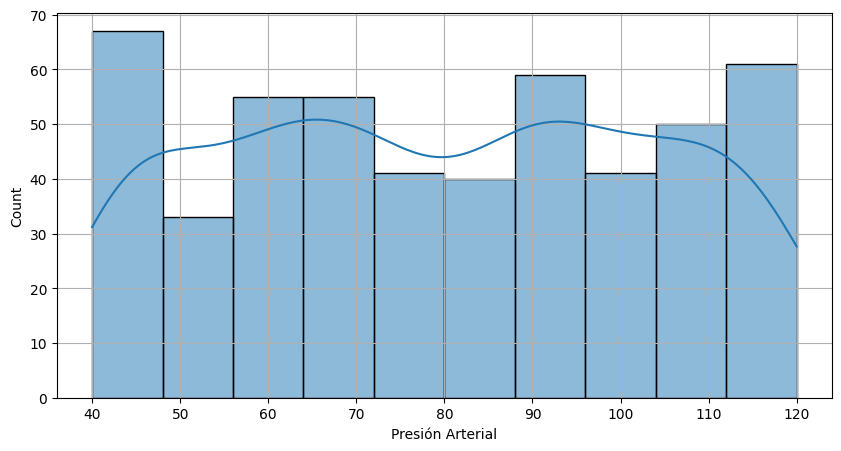

Número de datos por intervalo:
[67 33 55 55 41 40 59 41 50 61]
Intervalos inferiores:
[ 40.  48.  56.  64.  72.  80.  88.  96. 104. 112.]
Intervalos superiores:
[ 48.  56.  64.  72.  80.  88.  96. 104. 112. 120.]
Media Bello: 80.04780876494024
Desviación Bello: 23.91347503035003
Asimetría Bello: -0.0077317746783137934
Curtosis Bello: -1.271482177133099


In [ ]:
u_bello, sigma_bello, Cas_bello, Kur_bello, tabla_bello = caracterizacion(bello_v)
print("Media Bello:",u_bello)
print("Desviación Bello:",sigma_bello)
print("Asimetría Bello:",Cas_bello)
print("Curtosis Bello:",Kur_bello)

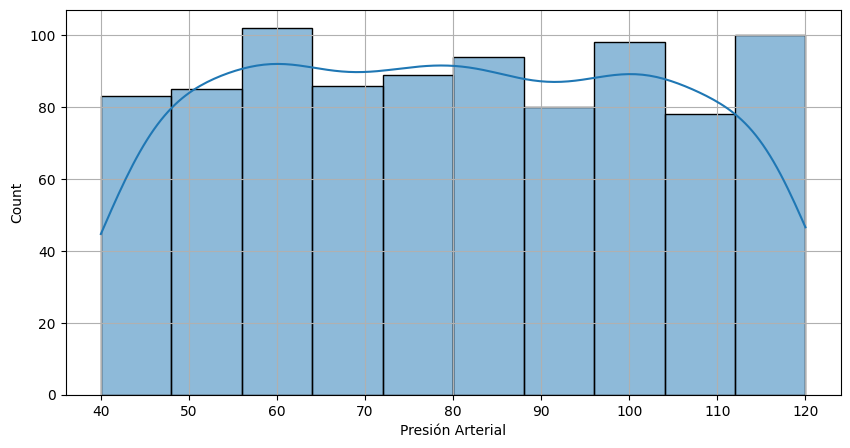

Número de datos por intervalo:
[ 83  85 102  86  89  94  80  98  78 100]
Intervalos inferiores:
[ 40.  48.  56.  64.  72.  80.  88.  96. 104. 112.]
Intervalos superiores:
[ 48.  56.  64.  72.  80.  88.  96. 104. 112. 120.]
Media Medellin: 80.3173184357542
Desviación Medellin: 22.957378083127683
Asimetría Medellin: 0.013701335997018426
Curtosis Medellin: -1.2197783554124608


In [ ]:
u_med, sigma_med, Cas_med, Kur_med, tabla_med = caracterizacion(medellin_v)
print("Media Medellin:",u_med)
print("Desviación Medellin:",sigma_med)
print("Asimetría Medellin:",Cas_med)
print("Curtosis Medellin:",Kur_med)

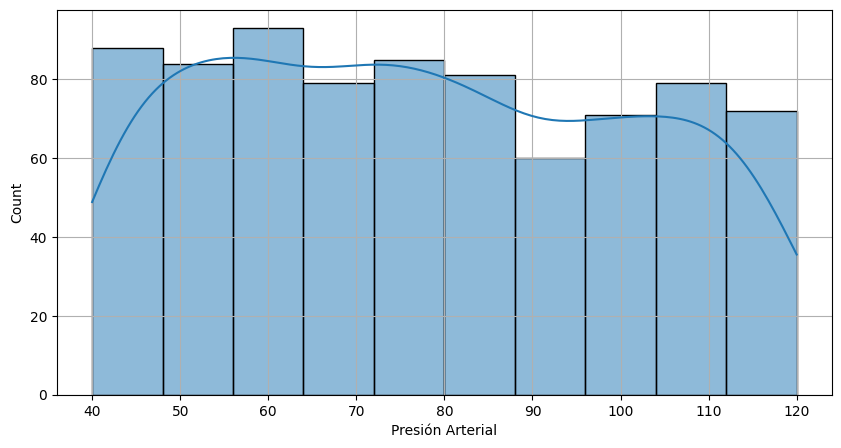

Número de datos por intervalo:
[88 84 93 79 85 81 60 71 79 72]
Intervalos inferiores:
[ 40.  48.  56.  64.  72.  80.  88.  96. 104. 112.]
Intervalos superiores:
[ 48.  56.  64.  72.  80.  88.  96. 104. 112. 120.]
Media Envigado: 78.23232323232322
Desviación Envigado: 23.05431806563097
Asimetría Envigado: 0.12069795484222297
Curtosis Envigado: -1.2189894307813185


In [ ]:
u_env, sigma_env, Cas_env, Kur_env, tabla_env = caracterizacion(envigado_v)
print("Media Envigado:",u_env)
print("Desviación Envigado:",sigma_env)
print("Asimetría Envigado:",Cas_env)
print("Curtosis Envigado:",Kur_env)

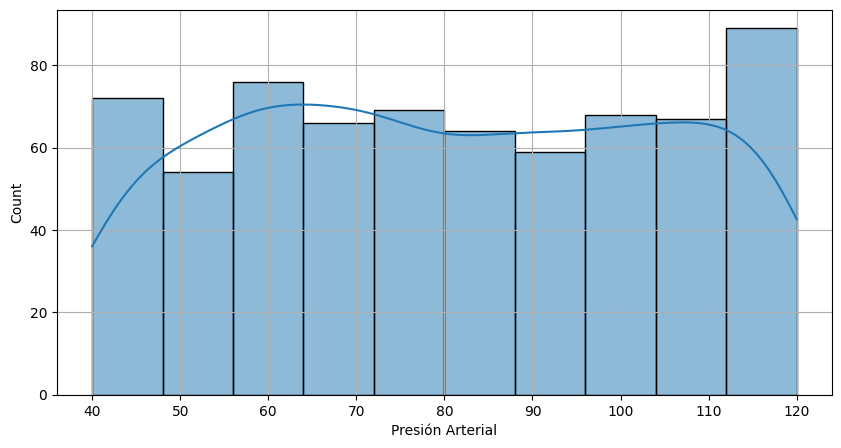

Número de datos por intervalo:
[72 54 76 66 69 64 59 68 67 89]
Intervalos inferiores:
[ 40.  48.  56.  64.  72.  80.  88.  96. 104. 112.]
Intervalos superiores:
[ 48.  56.  64.  72.  80.  88.  96. 104. 112. 120.]
Media Itagui: 81.04093567251462
Desviación Itagui: 23.585940089060493
Asimetría Itagui: -0.02082641141077745
Curtosis Itagui: -1.2578866104320579


In [ ]:
u_ita, sigma_ita, Cas_ita, Kur_ita, tabla_ita = caracterizacion(itagui_v)
print("Media Itagui:",u_ita)
print("Desviación Itagui:",sigma_ita)
print("Asimetría Itagui:",Cas_ita)
print("Curtosis Itagui:",Kur_ita)

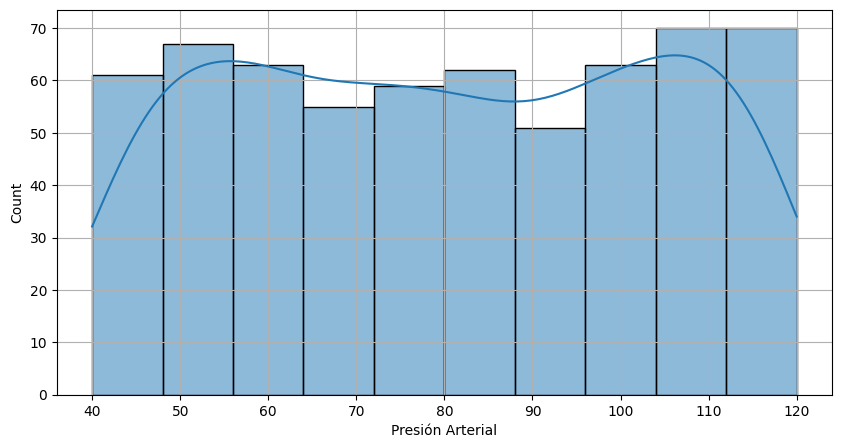

Número de datos por intervalo:
[61 67 63 55 59 62 51 63 70 70]
Intervalos inferiores:
[ 40.  48.  56.  64.  72.  80.  88.  96. 104. 112.]
Intervalos superiores:
[ 48.  56.  64.  72.  80.  88.  96. 104. 112. 120.]
Media Sabaneta: 80.59903381642512
Desviación Sabaneta: 23.555230585909747
Asimetría Sabaneta: -0.017286974744701027
Curtosis Sabaneta: -1.29364014605308


In [ ]:
u_sab, sigma_sab, Cas_sab, Kur_sab, tabla_sab = caracterizacion(sabaneta_v)
print("Media Sabaneta:",u_sab)
print("Desviación Sabaneta:",sigma_sab)
print("Asimetría Sabaneta:",Cas_sab)
print("Curtosis Sabaneta:",Kur_sab)

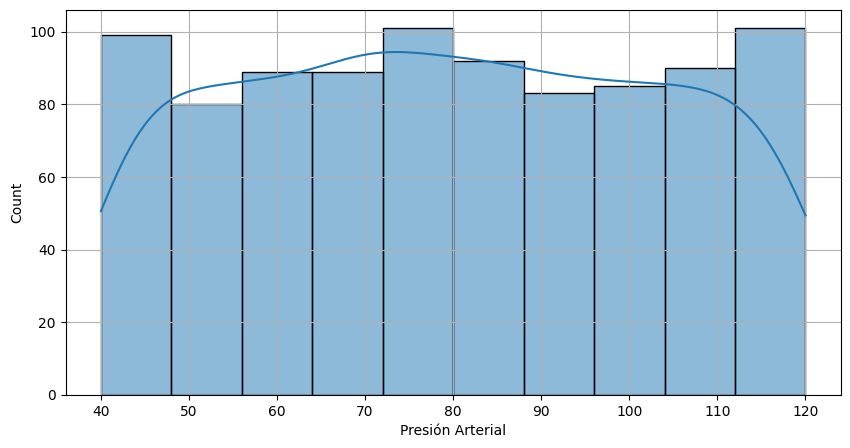

Número de datos por intervalo:
[ 99  80  89  89 101  92  83  85  90 101]
Intervalos inferiores:
[ 40.  48.  56.  64.  72.  80.  88.  96. 104. 112.]
Intervalos superiores:
[ 48.  56.  64.  72.  80.  88.  96. 104. 112. 120.]
Media Caldas: 80.18041804180419
Desviación Caldas: 23.215317091955185
Asimetría Caldas: 0.0004148999735990874
Curtosis Caldas: -1.2132266731094932


In [ ]:
u_cal, sigma_cal, Cas_cal, Kur_cal, tabla_cal = caracterizacion(caldas_v)
print("Media Caldas:",u_cal)
print("Desviación Caldas:",sigma_cal)
print("Asimetría Caldas:",Cas_cal)
print("Curtosis Caldas:",Kur_cal)

Inicialmente, encontramos que Medellín es la que presenta mayor similitud con Sabaneta. Esto se evidencia en la cercanía de sus valores de media, desviación estándar, asimetría y curtosis,

4. Estimación de la Teoría de Credibilidad

In [ ]:
def caracterizacion(variable):

  np.set_printoptions(suppress=True)

  NI = 10

  # Handle cases where variable might be empty or have too few unique values for histogram
  if len(variable) == 0:
      return 0, 0, 0, 0, pd.DataFrame()

  # Adjust bins if data range is too small
  min_val = variable.min()
  max_val = variable.max()
  if min_val == max_val:
      # If all values are the same, create a single bin
      bins = [min_val - 1, max_val + 1]
  else:
      bins = NI

  counts, bin_edges = np.histogram(variable, bins=bins)

  # Avoid division by zero if counts is empty
  if counts.sum() == 0:
      return 0, 0, 0, 0, pd.DataFrame()

  # print("Número de datos por intervalo:")
  # print(counts)

  # print("Intervalos inferiores:")
  # print(bin_edges[:-1])

  # print("Intervalos superiores:")
  # print(bin_edges[1:])

  XC = (bin_edges[:-1] + bin_edges[1:]) / 2

  Tabla = np.column_stack((bin_edges[:-1], bin_edges[1:], XC, counts))

  df = pd.DataFrame(Tabla, columns=['LI','LS','XC','ND'])

  fr = counts / np.sum(counts)

  u = np.sum(XC * fr)
  sigma2 = np.sum(fr * (XC - u)**2)
  sigma = np.sqrt(sigma2)
  # Handle potential division by zero for Cas and Kur if sigma is 0
  Cas = np.sum(fr * (XC - u)**3) / sigma**3 if sigma != 0 else 0
  Kur = (np.sum(fr * (XC - u)**4) / sigma**4) - 3 if sigma != 0 else -3 # Kurtosis for single point is -3

  return u, sigma, Cas, Kur, df

def calculate_credibility(observed_data, external_data):
  # Caracterización de los datos observados
  uo, sigmao, Caso, Kurto, dfo = caracterizacion(observed_data)

  # Caracterización de los datos externos
  ue, sigmae, Case, Kurte, dfe = caracterizacion(external_data)

  # Número de datos
  NDo = len(observed_data)
  NDe = len(external_data)

  # Media hipotética
  uhat = (NDo * uo + NDe * ue) / (NDo + NDe)

  # EPV (Expected Process Variance)
  EPV = (NDo * sigmao**2 + NDe * sigmae**2) / (NDo + NDe)

  # VHM (Variance of Hypothetical Means)
  VHM = ((NDo * uo**2 + NDe * ue**2) / (NDo + NDe)) - uhat**2

  # Factor de credibilidad
  # Avoid division by zero if VHM is too small or zero
  fc = EPV / VHM if VHM != 0 else float('inf')

  # Credibilidad
  # Ensure NDo + fc is not zero before division
  Cr = 1 - (NDo / (NDo + fc)) if (NDo + fc) != 0 else 0

  # Parámetro integrado (media)
  PEs = Cr * uo + (1 - Cr) * ue

  return Cr, PEs

# Base de datos interna (Sucursal Sabaneta)
LDA_observed = sabaneta_v

cities = {
    'Bello': bello_v,
    'Medellín': medellin_v,
    'Envigado': envigado_v,
    'Itagui': itagui_v,
    'Caldas': caldas_v
}

credibility_results = []

for city_name, city_data in cities.items():
    Cr, PEs = calculate_credibility(LDA_observed, city_data)
    credibility_results.append({
        'Sucursal Externa': city_name,
        'Credibilidad': Cr,
        'Media Integrada': PEs
    })

df_credibility_results = pd.DataFrame(credibility_results)
display(df_credibility_results)

,Sucursal Externa,Credibilidad,Media Integrada
0,Bello,0.923422,80.556822
1,Medellín,0.978343,80.592933
2,Envigado,0.387352,79.149073
3,Itagui,0.948373,80.621848
4,Caldas,0.954094,80.579817


Tras aplicar la Teoría de la Credibilidad para determinar la sede de mayor afinidad con Sabaneta, se concluye que la sucursal de Envigado es la opción óptima para la integración de los pacientes. Aunque otras sedes como Medellín presentan factores de credibilidad cercanos a 1, en este modelo actuarial, un valor de $Z$ más bajo indica una mayor similitud estructural. Envigado, con un índice de 0.3873, es la sucursal que más se aproxima al escenario ideal de "identidad propia" ($Z = 0.0$), lo que significa que requiere el menor ajuste estadístico para absorber la población de Sabaneta sin distorsionar los datos.

5. Tabla estadística antes de integrar

In [ ]:
# Caracterización Sabaneta
u_sab, sigma_sab, asim_sab, kurt_sab, df_sab = caracterizacion(sabaneta_v)

# Caracterización Envigado
u_env, sigma_env, asim_env, kurt_env, df_env = caracterizacion(envigado_v)

# Construcción tabla comparativa
tabla_stats = pd.DataFrame({
    "Sucursal": ["Sabaneta", "Envigado"],
    "Media": [u_sab, u_env],
    "Desviacion": [sigma_sab, sigma_env],
    "Asimetria": [asim_sab, asim_env],
    "Curtosis": [kurt_sab, kurt_env]
})

display(tabla_stats)

,Sucursal,Media,Desviacion,Asimetria,Curtosis
0,Sabaneta,80.599034,23.555231,-0.017287,-1.293640
1,Envigado,78.232323,23.054318,0.120698,-1.218989


6. **Método Aceptación/Rechazo II: Comparación de Valores de Pertenencia (VPo > VPe)**

Este método integra un dato de la sucursal externa (Envigado) en la interna (Sabaneta) si el valor de pertenencia de ese dato a la distribución de Sabaneta es mayor que su valor de pertenencia a la distribución de Envigado.

In [ ]:
# LDAo: Datos observados (Sabaneta)
# LDAe: Datos externos (Envigado)

LDAint2 = np.copy(sabaneta_v.values) # Inicializamos con los valores de Sabaneta

# Aseguramos que se usen los datos y estadísticas de Envigado para LDAe, ue, sigmae
LDAe = envigado_v
ue = u_env
sigmae = sigma_env

for k in range(len(LDAe)): # Iteramos sobre los datos externos (Envigado)
  VPo = np.exp(-0.5 * ((uo - LDAe.iloc[k]) / sigmao)**2) # Valor de pertenencia a Sabaneta
  VPe = np.exp(-0.5 * ((ue - LDAe.iloc[k]) / sigmae)**2) # Valor de pertenencia a Envigado

  if VPo > VPe:
    LDAint2 = np.append(LDAint2, LDAe.iloc[k])

# Caracterización de los datos integrados
ui2, sigmai2, Casi2, Kuri2, dfi2 = caracterizacion(LDAint2)

print("--- Resultados Método Aceptación/Rechazo II ---")
print("La media de los datos integrados es:", ui2)
print("La media de los datos observados (Sabaneta) es:", uo)
print("La media de los datos externos (Envigado) es:", ue) # Corregido para reflejar Envigado

duoui2 = np.abs((uo - ui2) / uo) * 100
print("La discrepancia porcentual entre la media de Sabaneta y la integrada es:", duoui2)

--- Resultados Método Aceptación/Rechazo II ---
La media de los datos integrados es: 87.76422764227644
La media de los datos observados (Sabaneta) es: 80.59903381642512
La media de los datos externos (Envigado) es: 78.23232323232322
La discrepancia porcentual entre la media de Sabaneta y la integrada es: 8.88992520948947


El Método de Valores de Pertenencia, al integrar datos de Envigado en Sabaneta, resultó en una media combinada de aproximadamente 87.76. Esta cifra es notablemente superior a la media original de Sabaneta (80.60) y a la de Envigado (78.23). La discrepancia porcentual del 8.89% entre la media de Sabaneta y la integrada sugiere que este método introdujo un cambio significativo en el valor central de la distribución de Sabaneta. Si el objetivo es preservar las características originales de Sabaneta, una desviación de casi el 9% en la media podría ser considerada sustancial y potencialmente distorsionadora para el análisis posterior.

7. **Método de Aceptación/Rechazo III: Cuotas de Aceptación (f(x)/g(x) > aleatorio())**

Este método garantiza que la forma de distribución original no se distorsiona al establecer cuotas de aceptación probabilísticas.

In [ ]:
# LDAo: Datos observados (Sabaneta)
# LDAe: Datos externos (Envigado)

LDAint3 = np.copy(sabaneta_v.values) # Inicializamos con los valores de Sabaneta

# Aseguramos que se usen los datos y estadísticas de Envigado para LDAe, ue, sigmae
LDAe = envigado_v
ue = u_env
sigmae = sigma_env

for k in range(len(LDAe)): # Iteramos sobre los datos externos (Envigado)
  VPo = np.exp(-0.5 * ((uo - LDAe.iloc[k]) / sigmao)**2) # Valor de pertenencia a Sabaneta
  VPe = np.exp(-0.5 * ((ue - LDAe.iloc[k]) / sigmae)**2) # Valor de pertenencia a Envigado
  aleatorio = np.random.rand()

  if (VPo / VPe) > aleatorio:
    LDAint3 = np.append(LDAint3, LDAe.iloc[k])

# Caracterización de los datos integrados
ui3, sigmai3, Casi3, Kuri3, dfi3 = caracterizacion(LDAint3)

print("--- Resultados Método Aceptación/Rechazo III ---")
print("La media de los datos integrados es:", ui3)
print("La media de los datos observados (Sabaneta) es:", uo)
print("La media de los datos externos (Envigado) es:", ue) # Corregido para reflejar Envigado

duoui3 = np.abs((uo - ui3) / uo) * 100
print("La discrepancia porcentual entre la media de Sabaneta y la integrada es:", duoui3)

--- Resultados Método Aceptación/Rechazo III ---
La media de los datos integrados es: 79.71531272465852
La media de los datos observados (Sabaneta) es: 80.59903381642512
La media de los datos externos (Envigado) es: 78.23232323232322
La discrepancia porcentual entre la media de Sabaneta y la integrada es: 1.0964412970252144


El Método de cuotas ha integrado los datos de manera muy exitosa: la media de los datos integrados (79.72) es extremadamente cercana a la media original de Sabaneta (80.60), con una discrepancia porcentual mínima de solo 1.10%. Esto demuestra que el método ha mantenido la estructura estadística original de Sabaneta de forma muy efectiva al integrar los datos de Envigado, lo cual es ideal para conservar la representatividad de la base de datos.

In [ ]:
num_original_sabaneta = len(sabaneta_v)

# Método Aceptación/Rechazo II
num_integrados_ar2 = len(LDAint2)
num_aniadidos_ar2 = num_integrados_ar2 - num_original_sabaneta

print(f"Método Aceptación/Rechazo II: Se añadieron {num_aniadidos_ar2} datos (Total: {num_integrados_ar2})")

# Método Aceptación/Rechazo III
num_integrados_ar3 = len(LDAint3)
num_aniadidos_ar3 = num_integrados_ar3 - num_original_sabaneta

print(f"Método Aceptación/Rechazo III: Se añadieron {num_aniadidos_ar3} datos (Total: {num_integrados_ar3})")

Método Aceptación/Rechazo II: Se añadieron 363 datos (Total: 984)
Método Aceptación/Rechazo III: Se añadieron 770 datos (Total: 1391)


- Método Aceptación/Rechazo II: Se añadieron 363 datos, lo que resultó en un total de 984 datos para la base integrada.
- Método Aceptación/Rechazo III: Se añadieron 770 datos, con un total de 1391 datos integrados.

In [ ]:
df_resultados_final = pd.DataFrame({
    "Escenario": [
        "Sabaneta original",
        "Integrado (Aceptación/Rechazo II)",
        "Integrado (Aceptación/Rechazo III)"
    ],
    "Media": [uo, ui2, ui3],
    "Desviación": [sigmao, sigmai2, sigmai3],
    "Asimetría": [Caso, Casi2, Casi3],
    "Curtosis": [Kurto, Kuri2, Kuri3]
})

display(df_resultados_final)

,Escenario,Media,Desviación,Asimetría,Curtosis
0,Sabaneta original,80.599034,23.555231,-0.017287,-1.293640
1,Integrado (Aceptación/Rechazo II),87.764228,22.064422,-0.508003,-0.861862
2,Integrado (Aceptación/Rechazo III),79.715313,23.201664,0.038481,-1.251325


Al analizar las medidas de tendencia central y dispersión, el Método de Cuotas demuestra ser el más efectivo para integrar datos manteniendo las características estadísticas de la distribución original de Sabaneta. Su media (79.72) es la más cercana a la original de Sabaneta (80.60), y su desviación estándar (23.20), asimetría (0.04) y curtosis (-1.25) también se mantienen significativamente más próximas a los valores originales que el Método de Aceptación/Rechazo II.

En contraste, el Método de Valores de Pertenencia (con una media de 87.76 y una desviación de 22.06) introduce cambios más pronunciados en la media y una reducción en la dispersión (desviación estándar), además de alterar más notablemente la forma de la distribución (asimetría y curtosis). Esto sugiere que, si el objetivo es preservar la forma y las características estadísticas de la distribución original de Sabaneta, el Método de Aceptación/Rechazo III es la opción superior, ya que logra una integración más armónica y menos distorsionadora.

## Conclusión Final del Caso de Estudio: Integración de Sucursales de Salud

El objetivo central de este caso de estudio fue evaluar el proceso de integración de datos en una entidad prestadora de salud, enfocándose en la consolidación de la sucursal de Sabaneta con otra sede. Para ello, se utilizó la variable `BloodPressure` como indicador clave y se aplicaron herramientas estadísticas y de credibilidad para tomar decisiones informadas.

### 1. Caracterización Estadística y Afinidad de Sucursales

Inicialmente, se realizó una caracterización estadística de la variable `BloodPressure` para todas las sucursales. Esto permitió identificar similitudes en las distribuciones de datos. Aunque Medellín mostró una alta similitud en términos de sus características estadísticas básicas (media, desviación estándar, asimetría y curtosis), el análisis posterior con la Teoría de la Credibilidad refinó esta evaluación.

### 2. Teoría de la Credibilidad: Identificación de la Sucursal Óptima

La aplicación de la Teoría de la Credibilidad reveló que **Envigado** era la opción más adecuada para la integración de los pacientes de Sabaneta. A pesar de que otras ciudades como Medellín o Caldas presentaban factores de credibilidad elevados, el modelo actuarial indicó que Envigado ofrecía la menor "distorsión" o el menor ajuste estadístico para absorber la población de Sabaneta. Esto se traduce en una mayor preservación de las características estructurales de los datos originales de Sabaneta.

### 3. Métodos de Integración de Datos: Comparación y Selección

Se evaluaron dos métodos de integración basados en el concepto de aceptación y rechazo, utilizando Envigado como la sucursal externa:

*   **Método de Aceptación/Rechazo II (Valores de Pertenencia)**:
    Este método integró 363 datos adicionales. Sin embargo, alteró significativamente la media de los datos integrados (87.76) en comparación con la media original de Sabaneta (80.60), resultando en una discrepancia porcentual considerable del 8.89%. Esto indica que, si bien incrementó el volumen de datos, modificó notablemente las propiedades de tendencia central de la distribución original.

*   **Método de Aceptación/Rechazo III (Cuotas de Aceptación)**:
    Este método incorporó un mayor número de datos (770), elevando el total a 1391. Lo más relevante fue que la media de los datos integrados (79.72) se mantuvo extremadamente cercana a la media original de Sabaneta (80.60), con una mínima discrepancia porcentual del 1.10%. Además, las medidas de dispersión (desviación estándar) y forma (asimetría y curtosis) se conservaron de manera más fiel a la distribución original.

### Recomendación Final

Con base en los resultados obtenidos, se recomienda firmemente el uso del **Método de Aceptación/Rechazo III (Método de Cuotas)** para la integración de los pacientes de la sucursal de Sabaneta en Envigado. Este método demostró ser superior al lograr una integración eficiente y un aumento sustancial en el tamaño de la muestra, mientras minimiza la distorsión estadística de la variable `BloodPressure`.

La aplicación de este método asegurará que la base de datos resultante conserve las características esenciales de la población de Sabaneta, lo cual es crucial para mantener la validez y confiabilidad de los análisis clínicos y las operaciones de la entidad prestadora de salud tras el cierre de la sucursal. Esta integración armoniosa es clave para una transición exitosa y para la mejora continua de la eficiencia del servicio.